<a href="https://colab.research.google.com/github/hurryzyn/player-analysis-seriea/blob/main/SerieA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [5]:
import gdown

folder_id_serieA = '1ycdRuRq4V7f6xHLoatMjSnbajZIN_m8z'
gdown.download_folder(id=folder_id_serieA, remaining_ok=True, quiet=True)


['/content/SerieA23_24/accurate_cross_team.csv',
 '/content/SerieA23_24/accurate_long_balls_team.csv',
 '/content/SerieA23_24/accurate_pass_team.csv',
 '/content/SerieA23_24/big_chance_missed_team.csv',
 '/content/SerieA23_24/big_chance_team.csv',
 '/content/SerieA23_24/clean_sheet_team.csv',
 '/content/SerieA23_24/corner_taken_team.csv',
 '/content/SerieA23_24/effective_clearance_team.csv',
 '/content/SerieA23_24/expected_goals_conceded_team.csv',
 '/content/SerieA23_24/expected_goals_team.csv',
 '/content/SerieA23_24/fk_foul_lost_team.csv',
 '/content/SerieA23_24/goals_conceded_team_match.csv',
 '/content/SerieA23_24/interception_team.csv',
 '/content/SerieA23_24/ontarget_scoring_att_team.csv',
 '/content/SerieA23_24/penalty_conceded_team.csv',
 '/content/SerieA23_24/penalty_won_team.csv',
 '/content/SerieA23_24/player_accurate_long_balls.csv',
 '/content/SerieA23_24/player_accurate_passes.csv',
 '/content/SerieA23_24/player_big_chances_created.csv',
 '/content/SerieA23_24/player_big

In [6]:
import pandas as pd

base_path = 'SerieA23_24/'
df_xa = pd.read_csv(base_path + 'player_expected_assists_per_90.csv')
df_assists = pd.read_csv(base_path + 'player_top_assists.csv')
df_big_chances = pd.read_csv(base_path + 'player_big_chances_created.csv')
df_passes = pd.read_csv(base_path + 'player_accurate_passes.csv')
df_dribbles = pd.read_csv(base_path + 'player_contests_won.csv')
df_long_balls = pd.read_csv(base_path + 'player_accurate_long_balls.csv')
df_poss_won = pd.read_csv(base_path + 'player_possessions_won_attacking_third.csv')
df_interceptions = pd.read_csv(base_path + 'player_interceptions.csv')
df_clearances = pd.read_csv(base_path + 'player_effective_clearances.csv')
df_shots = pd.read_csv(base_path + 'player_total_scoring_attempts.csv')
df_chances_created = pd.read_csv(base_path + 'player_total_assists_in_attack.csv')

print("DONE BOSQ")

DONE BOSQ


In [7]:
raw_dfs = {
    'Expected Assists': df_xa,
    'Actual Assists': df_assists,
    'Big Chances': df_big_chances,
    'Accurate Passes': df_passes,
    'Dribbles': df_dribbles,
    'Long Balls': df_long_balls,
    'Possessions Won': df_poss_won,
    'Interceptions': df_interceptions,
    'Clearances': df_clearances,
    'Shots': df_shots,
    'Chances Created': df_chances_created
}

print("-- DATA QUALITY & ETL REPORT --")
for name, df in raw_dfs.items():
    total_missing = df.isnull().sum().sum()
    total_duplicates = df.duplicated().sum()

    print(f"Entity: {name}")
    print(f" - Shape: {df.shape[0]} rows, {df.shape[1]} columns")
    print(f" - Missing Values: {total_missing}")
    print(f" - Duplicate Rows: {total_duplicates}")
    print("-" * 40)

-- DATA QUALITY & ETL REPORT --
Entity: Expected Assists
 - Shape: 342 rows, 8 columns
 - Missing Values: 0
 - Duplicate Rows: 0
----------------------------------------
Entity: Actual Assists
 - Shape: 285 rows, 8 columns
 - Missing Values: 0
 - Duplicate Rows: 0
----------------------------------------
Entity: Big Chances
 - Shape: 322 rows, 8 columns
 - Missing Values: 0
 - Duplicate Rows: 0
----------------------------------------
Entity: Accurate Passes
 - Shape: 342 rows, 8 columns
 - Missing Values: 0
 - Duplicate Rows: 0
----------------------------------------
Entity: Dribbles
 - Shape: 314 rows, 8 columns
 - Missing Values: 0
 - Duplicate Rows: 0
----------------------------------------
Entity: Long Balls
 - Shape: 322 rows, 8 columns
 - Missing Values: 0
 - Duplicate Rows: 0
----------------------------------------
Entity: Possessions Won
 - Shape: 306 rows, 8 columns
 - Missing Values: 0
 - Duplicate Rows: 0
----------------------------------------
Entity: Interceptions
 - 

In [10]:
print("~~~ EDA ~~")
for name, df in raw_dfs.items():
    print(f"\nEntity: {name}")
    print(df.dtypes)
    display(df.head(3))
    print("-" * 60)

~~~ EDA ~~

Entity: Expected Assists
Rank                         int64
Player                      object
Team                        object
Expected Assists per 90    float64
Actual Assists per 90      float64
Minutes                      int64
Matches                      int64
Country                     object
dtype: object


,Rank,Player,Team,Expected Assists per 90,Actual Assists per 90,Minutes,Matches,Country
0,1,Aleksey Miranchuk,Atalanta,0.35,0.4,1170,27,RUS
1,2,Alexis Sánchez,Internazionale,0.34,0.6,751,23,CHI
2,3,Federico Dimarco,Internazionale,0.32,0.3,2105,30,ITA


------------------------------------------------------------

Entity: Actual Assists
Rank                   int64
Player                object
Team                  object
Assists              float64
Secondary Assists    float64
Minutes                int64
Matches                int64
Country               object
dtype: object


,Rank,Player,Team,Assists,Secondary Assists,Minutes,Matches,Country
0,1,Rafael Leao,Milan,9.0,8.1,2523,34,POR
1,2,Paulo Dybala,Roma,9.0,4.0,1973,28,ARG
2,3,Christian Pulisic,Milan,8.0,4.5,2620,36,USA


------------------------------------------------------------

Entity: Big Chances
Rank                     int64
Player                  object
Team                    object
Big Chances Created    float64
Total Assists          float64
Minutes                  int64
Matches                  int64
Country                 object
dtype: object


...

------------------------------------------------------------

Entity: Shots
Rank                          int64
Player                       object
Team                         object
Shots per 90                float64
Shot Conversion Rate (%)    float64
Minutes                       int64
Matches                       int64
Country                      object
dtype: object


,Rank,Player,Team,Shots per 90,Shot Conversion Rate (%),Minutes,Matches,Country
0,1,Dusan Vlahovic,Juventus,4.3,14.6,2317,33,SRB
1,2,Khvicha Kvaratskhelia,Napoli,4.2,8.6,2750,34,GEO
2,3,Victor Osimhen,Napoli,4.1,16.7,1990,25,NGA


------------------------------------------------------------

Entity: Chances Created
Rank                        int64
Player                     object
Team                       object
Chances Created           float64
Chances Created per 90    float64
Minutes                     int64
Matches                     int64
Country                    object
dtype: object


,Rank,Player,Team,Chances Created,Chances Created per 90,Minutes,Matches,Country
0,1,Matias Soulé,Frosinone,82.0,2.4,3136,36,ARG
1,2,Albert Gudmundsson,Genoa,81.0,2.4,3022,35,ISL
2,3,Matteo Politano,Napoli,71.0,2.7,2384,37,ITA


------------------------------------------------------------


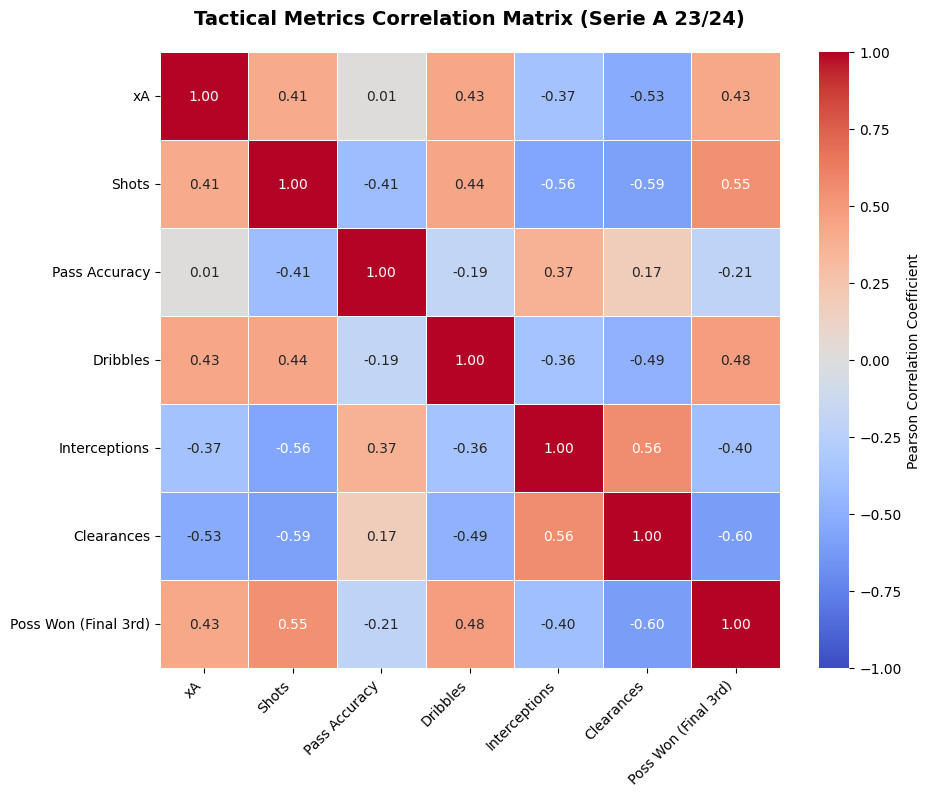

In [14]:
import matplotlib.pyplot as plt
import seaborn as sns
df_corr = df_xa[['Player', 'Expected Assists per 90']].merge(df_shots[['Player', 'Shots per 90']], on='Player', how='inner')
df_corr = df_corr.merge(df_passes[['Player', 'Pass Success (%)']], on='Player', how='inner')
df_corr = df_corr.merge(df_dribbles[['Player', 'Successful Dribbles per 90']], on='Player', how='inner')
df_corr = df_corr.merge(df_interceptions[['Player', 'Interceptions per 90']], on='Player', how='inner')
df_corr = df_corr.merge(df_clearances[['Player', 'Clearances per 90']], on='Player', how='inner')
df_corr = df_corr.merge(df_poss_won[['Player', 'Possessions Won in Final 3rd per 90']], on='Player', how='inner')

df_corr.columns = ['Player', 'xA', 'Shots', 'Pass Accuracy', 'Dribbles', 'Interceptions', 'Clearances', 'Poss Won (Final 3rd)']

corr_matrix = df_corr.drop(columns=['Player']).corr()

plt.figure(figsize=(10, 8))
sns.heatmap(
    corr_matrix,
    annot=True,
    cmap='coolwarm',
    fmt='.2f',
    linewidths=0.5,
    vmin=-1,
    vmax=1,
    cbar_kws={'label': 'Pearson Correlation Coefficient'}
)

plt.title('Tactical Metrics Correlation Matrix (Serie A 23/24)', pad=20, fontsize=14, fontweight='bold')
plt.xticks(rotation=45, ha='right', fontsize=10)
plt.yticks(fontsize=10)
plt.savefig('correlation_heatmap.png', dpi=300, bbox_inches='tight')
plt.show()

In [12]:
df_hidden_creative = pd.merge(df_xa[['Player', 'Team', 'Expected Assists per 90']], df_assists[['Player', 'Assists']], on='Player')
df_hidden_creative = pd.merge(df_hidden_creative, df_big_chances[['Player', 'Big Chances Created']], on='Player')

df_line_breaker = pd.merge(df_dribbles[['Player', 'Team', 'Successful Dribbles per 90']], df_long_balls[['Player', 'Accurate Long Balls per 90']], on='Player')

df_press_trigger = pd.merge(df_poss_won[['Player', 'Team', 'Possessions Won in Final 3rd per 90']], df_interceptions[['Player', 'Interceptions per 90']], on='Player')

df_pass_risk = pd.merge(df_passes[['Player', 'Team', 'Pass Success (%)']], df_xa[['Player', 'Expected Assists per 90']], on='Player')

df_defender_profile = pd.merge(df_interceptions[['Player', 'Team', 'Interceptions per 90']], df_clearances[['Player', 'Clearances per 90']], on='Player')

df_false_nine = pd.merge(df_shots[['Player', 'Team', 'Shots per 90']], df_chances_created[['Player', 'Chances Created per 90']], on='Player')

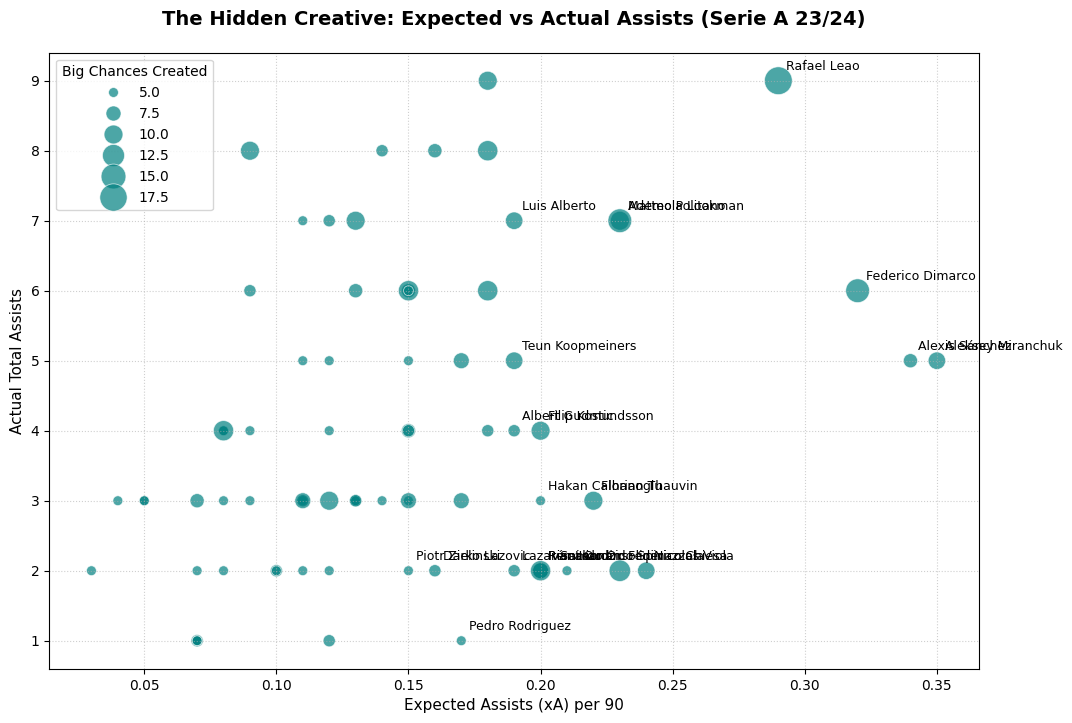

In [17]:
import matplotlib.pyplot as plt
import seaborn as sns

df_viz_1 = df_hidden_creative[df_hidden_creative['Big Chances Created'] >= 5].copy()

plt.figure(figsize=(12, 8))
sns.scatterplot(
    data=df_viz_1,
    x='Expected Assists per 90',
    y='Assists',
    size='Big Chances Created',
    sizes=(50, 400),
    alpha=0.7,
    color='teal'
)

for i, row in df_viz_1.iterrows():
    if row['Expected Assists per 90'] > 0.18 or (row['Expected Assists per 90'] > 0.12 and row['Assists'] < 3):
        plt.text(row['Expected Assists per 90'] + 0.003, row['Assists'] + 0.15, row['Player'], fontsize=9)

plt.title('The Hidden Creative: Expected vs Actual Assists (Serie A 23/24)', pad=20, fontsize=14, fontweight='bold')
plt.xlabel('Expected Assists (xA) per 90', fontsize=11)
plt.ylabel('Actual Total Assists', fontsize=11)
plt.grid(True, linestyle=':', alpha=0.6)
plt.show()

In [18]:
df_hidden_table = df_viz_1[(df_viz_1['Expected Assists per 90'] >= 0.15) & (df_viz_1['Assists'] <= 3)].copy()

df_hidden_table = df_hidden_table.sort_values(by='Expected Assists per 90', ascending=False)

df_hidden_table.reset_index(drop=True, inplace=True)
df_hidden_table = df_hidden_table[['Player', 'Team', 'Expected Assists per 90', 'Assists', 'Big Chances Created']]

display(df_hidden_table)

,Player,Team,Expected Assists per 90,Assists,Big Chances Created
0,Nicolas Viola,Cagliari,0.24,2.0,9.0
1,Federico Chiesa,Juventus,0.23,2.0,12.0
2,Florian Thauvin,Udinese,0.22,3.0,10.0
3,Leonardo Spinazzola,Roma,0.21,2.0,5.0
4,Hakan Calhanoglu,Internazionale,0.20,3.0,5.0
5,Ivan Ilic,Torino,0.20,2.0,8.0
6,Rémi Oudin,Lecce,0.20,2.0,8.0
7,Riccardo Orsolini,Bologna,0.20,2.0,11.0
8,Lazar Samardzic,Udinese,0.19,2.0,6.0
9,Giacomo Raspadori,Napoli,0.17,3.0,8.0


In [19]:
df_line_breaker_table = df_line_breaker[(df_line_breaker['Successful Dribbles per 90'] >= 1.0) & (df_line_breaker['Accurate Long Balls per 90'] >= 3.0)].copy()

df_line_breaker_table['Progression Score'] = df_line_breaker_table['Successful Dribbles per 90'] + df_line_breaker_table['Accurate Long Balls per 90']

df_line_breaker_table = df_line_breaker_table.sort_values(by='Progression Score', ascending=False)

df_line_breaker_table.reset_index(drop=True, inplace=True)

display(df_line_breaker_table)

,Player,Team,Successful Dribbles per 90,Accurate Long Balls per 90,Progression Score
0,Yacine Adli,Milan,1.4,5.0,6.4
1,Alexis Sánchez,Internazionale,1.4,3.4,4.8
2,Alfred Duncan,Fiorentina,1.0,3.6,4.6
3,Suat Serdar,Verona,1.0,3.5,4.5


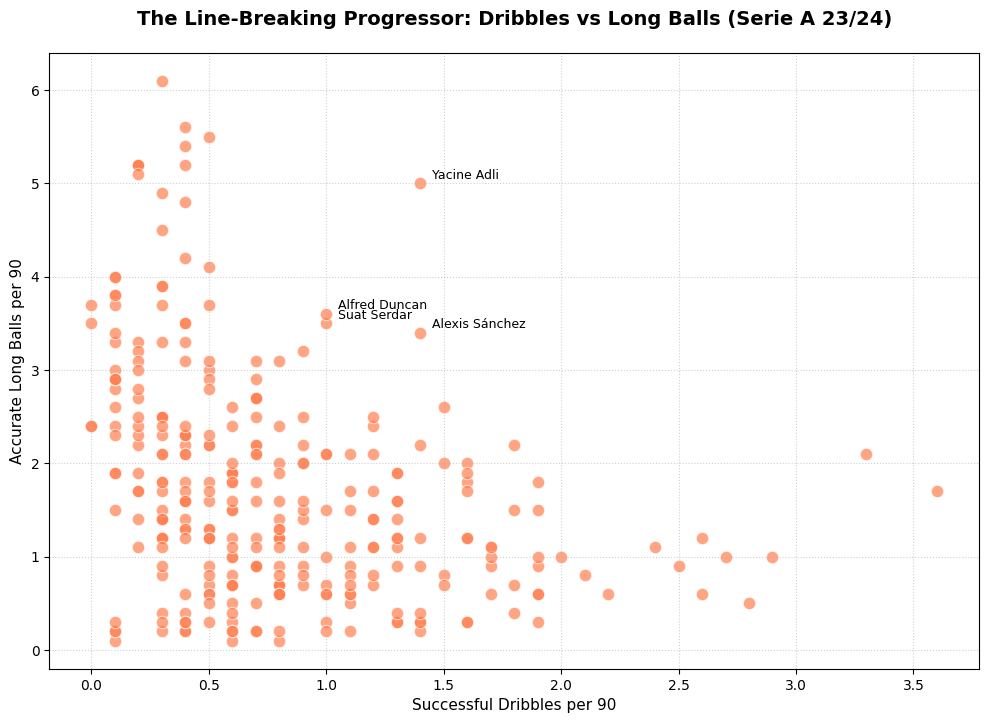

In [20]:
plt.figure(figsize=(12, 8))

sns.scatterplot(
    data=df_line_breaker,
    x='Successful Dribbles per 90',
    y='Accurate Long Balls per 90',
    alpha=0.7,
    color='coral',
    s=80
)

for i, row in df_line_breaker_table.head(12).iterrows():
    plt.text(row['Successful Dribbles per 90'] + 0.05, row['Accurate Long Balls per 90'] + 0.05, row['Player'], fontsize=9)

plt.title('The Line-Breaking Progressor: Dribbles vs Long Balls (Serie A 23/24)', pad=20, fontsize=14, fontweight='bold')
plt.xlabel('Successful Dribbles per 90', fontsize=11)
plt.ylabel('Accurate Long Balls per 90', fontsize=11)
plt.grid(True, linestyle=':', alpha=0.6)
plt.show()

In [21]:
df_press_table = df_press_trigger[(df_press_trigger['Possessions Won in Final 3rd per 90'] >= 0.8) & (df_press_trigger['Interceptions per 90'] <= 1.0)].copy()

df_press_table = df_press_table.sort_values(by='Possessions Won in Final 3rd per 90', ascending=False)

df_press_table.reset_index(drop=True, inplace=True)
display(df_press_table.head(10))

,Player,Team,Possessions Won in Final 3rd per 90,Interceptions per 90
0,Antonin Barak,Fiorentina,1.6,0.2
1,Cristian Volpato,Sassuolo,1.4,0.1
2,Gianluca Gaetano,Cagliari,1.2,0.4
3,Samuele Mulattieri,Sassuolo,1.2,0.2
4,Reinier,Frosinone,1.1,0.8
5,Charles De Ketelaere,Atalanta,1.1,0.3
6,Lameck Banda,Lecce,1.1,0.2
7,Christian Kouamé,Fiorentina,1.0,0.2
8,Kaio Jorge,Frosinone,1.0,0.1
9,Alexis Sánchez,Internazionale,1.0,0.1


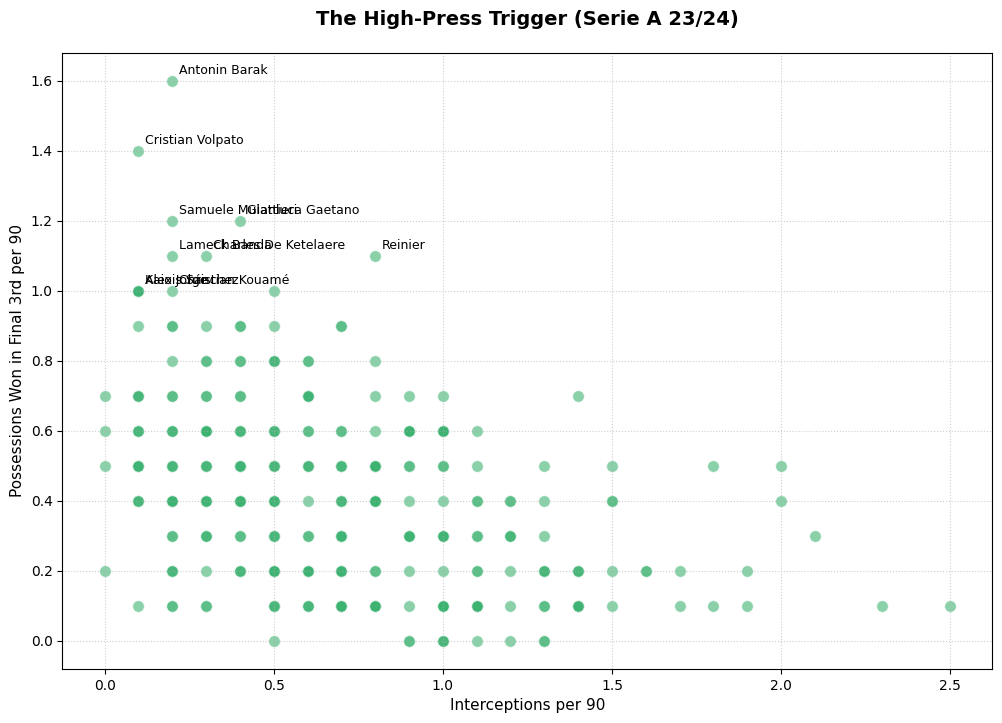

In [22]:
plt.figure(figsize=(12, 8))

sns.scatterplot(
    data=df_press_trigger,
    x='Interceptions per 90',
    y='Possessions Won in Final 3rd per 90',
    alpha=0.6,
    color='mediumseagreen',
    s=70
)

for i, row in df_press_table.head(10).iterrows():
    plt.text(row['Interceptions per 90'] + 0.02, row['Possessions Won in Final 3rd per 90'] + 0.02, row['Player'], fontsize=9)

plt.title('The High-Press Trigger (Serie A 23/24)', pad=20, fontsize=14, fontweight='bold')
plt.xlabel('Interceptions per 90', fontsize=11)
plt.ylabel('Possessions Won in Final 3rd per 90', fontsize=11)
plt.grid(True, linestyle=':', alpha=0.6)
plt.show()

In [23]:
df_pass_risk_table = df_pass_risk[(df_pass_risk['Pass Success (%)'] <= 85.0) & (df_pass_risk['Expected Assists per 90'] >= 0.15)].copy()

df_pass_risk_table = df_pass_risk_table.sort_values(by='Expected Assists per 90', ascending=False)

df_pass_risk_table.reset_index(drop=True, inplace=True)
display(df_pass_risk_table.head(10))

,Player,Team,Pass Success (%),Expected Assists per 90
0,Aleksey Miranchuk,Atalanta,78.0,0.35
1,Alexis Sánchez,Internazionale,80.9,0.34
2,Rafael Leao,Milan,80.0,0.29
3,Samuel Chukwueze,Milan,81.7,0.24
4,Marko Arnautovic,Internazionale,77.1,0.24
5,Nicolas Viola,Cagliari,74.3,0.24
6,Ademola Lookman,Atalanta,80.2,0.23
7,Federico Chiesa,Juventus,77.3,0.23
8,Matteo Politano,Napoli,83.0,0.23
9,Florian Thauvin,Udinese,77.8,0.22


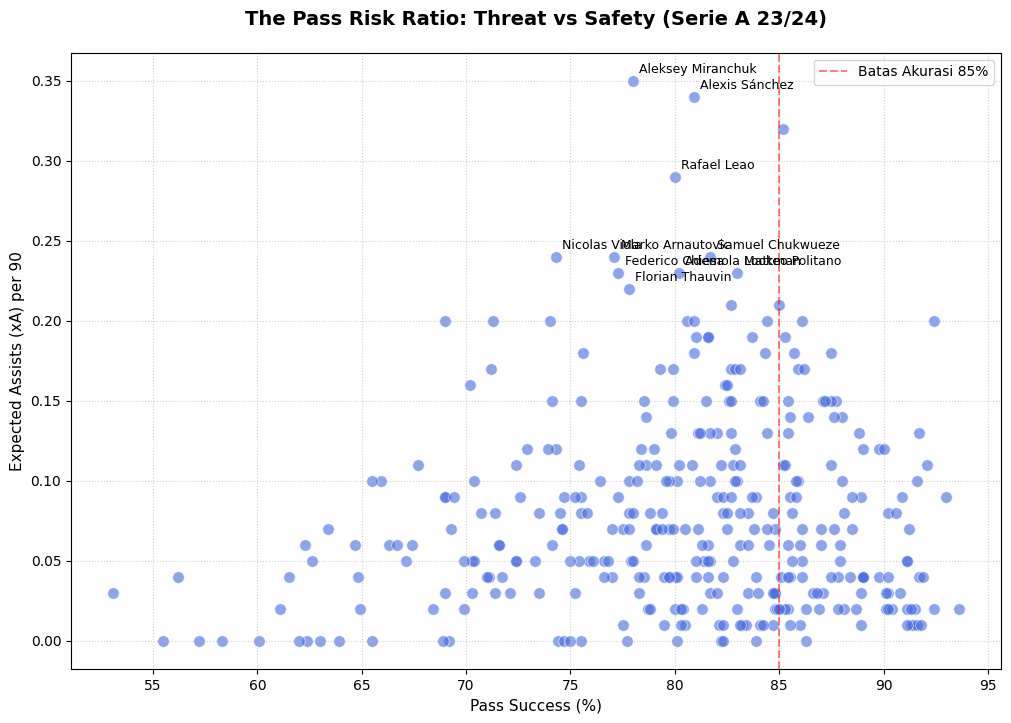

In [24]:
plt.figure(figsize=(12, 8))

sns.scatterplot(
    data=df_pass_risk,
    x='Pass Success (%)',
    y='Expected Assists per 90',
    alpha=0.6,
    color='royalblue',
    s=70
)


for i, row in df_pass_risk_table.head(10).iterrows():
    plt.text(row['Pass Success (%)'] + 0.3, row['Expected Assists per 90'] + 0.005, row['Player'], fontsize=9)


plt.axvline(x=85, color='red', linestyle='--', alpha=0.5, label='Batas Akurasi 85%')

plt.title('The Pass Risk Ratio: Threat vs Safety (Serie A 23/24)', pad=20, fontsize=14, fontweight='bold')
plt.xlabel('Pass Success (%)', fontsize=11)
plt.ylabel('Expected Assists (xA) per 90', fontsize=11)
plt.legend()
plt.grid(True, linestyle=':', alpha=0.6)
plt.show()

In [25]:
df_proactive_defender = df_defender_profile[(df_defender_profile['Interceptions per 90'] >= 1.2) & (df_defender_profile['Clearances per 90'] <= 3.0)].copy()

df_proactive_defender = df_proactive_defender.sort_values(by='Interceptions per 90', ascending=False)
df_proactive_defender.reset_index(drop=True, inplace=True)

display(df_proactive_defender.head(10))

,Player,Team,Interceptions per 90,Clearances per 90
0,Alessandro Vogliacco,Genoa,2.3,2.9
1,Giorgio Scalvini,Atalanta,2.1,2.3
2,Adrien Tamèze,Torino,2.0,1.0
3,Alberto Grassi,Empoli,2.0,1.7
4,Riccardo Calafiori,Bologna,1.9,2.8
5,Milan Badelj,Genoa,1.8,1.8
6,Benjamin Pavard,Internazionale,1.7,2.3
7,Juan Cabal,Verona,1.6,2.8
8,Nicolo Rovella,Lazio,1.6,1.6
9,Morten Frendrup,Genoa,1.5,0.9


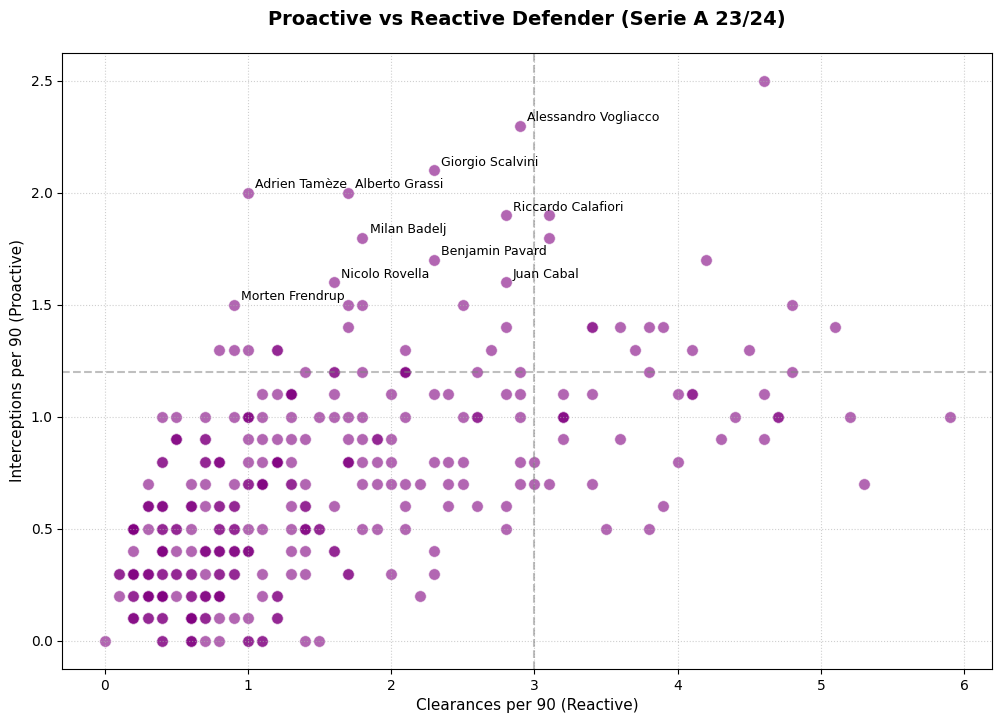

In [26]:
plt.figure(figsize=(12, 8))

sns.scatterplot(
    data=df_defender_profile,
    x='Clearances per 90',
    y='Interceptions per 90',
    alpha=0.6,
    color='purple',
    s=70
)

for i, row in df_proactive_defender.head(10).iterrows():
    plt.text(row['Clearances per 90'] + 0.05, row['Interceptions per 90'] + 0.02, row['Player'], fontsize=9)

plt.axvline(x=3.0, color='gray', linestyle='--', alpha=0.5)
plt.axhline(y=1.2, color='gray', linestyle='--', alpha=0.5)

plt.title('Proactive vs Reactive Defender (Serie A 23/24)', pad=20, fontsize=14, fontweight='bold')
plt.xlabel('Clearances per 90 (Reactive)', fontsize=11)
plt.ylabel('Interceptions per 90 (Proactive)', fontsize=11)
plt.grid(True, linestyle=':', alpha=0.6)
plt.show()

=== Tabel The System-First Creators ===


,Player,Team,Shots per 90,Chances Created per 90
0,Rémi Oudin,Lecce,1.7,2.9
1,Federico Dimarco,Internazionale,2.2,2.6
2,Luis Alberto,Lazio,2.2,2.5
3,Albert Gudmundsson,Genoa,1.7,2.4
4,Matias Soulé,Frosinone,2.4,2.4
5,Lazar Samardzic,Udinese,2.2,2.3
6,Cristian Volpato,Sassuolo,1.7,2.3
7,Alessandro Florenzi,Milan,1.7,2.3
8,Alexis Sánchez,Internazionale,2.2,2.2
9,Charles De Ketelaere,Atalanta,2.0,2.2


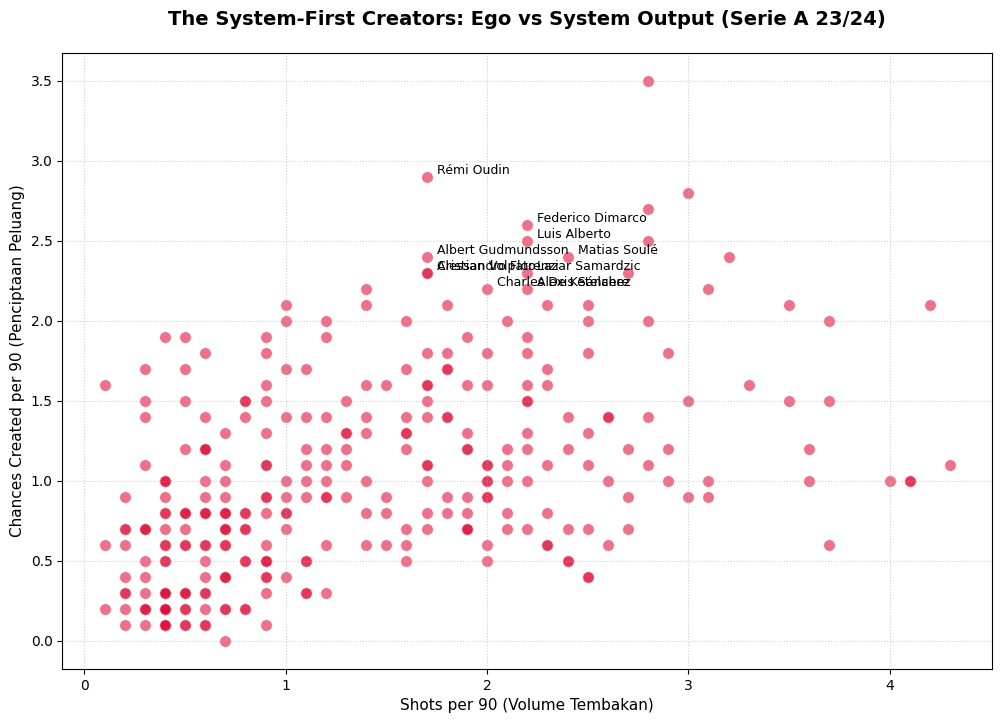

In [27]:
df_system_creators_table = df_false_nine[(df_false_nine['Shots per 90'] <= 2.5) & (df_false_nine['Chances Created per 90'] >= 1.5)].copy()
df_system_creators_table = df_system_creators_table.sort_values(by='Chances Created per 90', ascending=False)
df_system_creators_table.reset_index(drop=True, inplace=True)

print("=== Tabel The System-First Creators ===")
display(df_system_creators_table.head(10))

plt.figure(figsize=(12, 8))
sns.scatterplot(
    data=df_false_nine,
    x='Shots per 90',
    y='Chances Created per 90',
    alpha=0.6,
    color='crimson',
    s=70
)

for i, row in df_system_creators_table.head(10).iterrows():
    plt.text(row['Shots per 90'] + 0.05, row['Chances Created per 90'] + 0.02, row['Player'], fontsize=9)

plt.title('The System-First Creators: Ego vs System Output (Serie A 23/24)', pad=20, fontsize=14, fontweight='bold')
plt.xlabel('Shots per 90 (Volume Tembakan)', fontsize=11)
plt.ylabel('Chances Created per 90 (Penciptaan Peluang)', fontsize=11)
plt.grid(True, linestyle=':', alpha=0.6)
plt.show()